## Cell 1 - IMPORT

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

## Cell 2 - User Settings

In [2]:
# =========================
# User-configurable settings
# =========================

DATASET_FILE = "breast_cancer.tsv"

HIDDEN_NEURONS = 24

# Choose one of:
# "relu", "leaky_relu", "gelu", "tanh", "sigmoid"
HIDDEN_ACTIVATION = "gelu"

EPOCHS = 2048
BATCH_SIZE = 16
LEARNING_RATE = 0.00025

RANDOM_SEED = 435342

TEST_SIZE = 0.20

In [3]:
def set_random_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # More deterministic behaviour, though possibly slower on GPU
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_random_seed(RANDOM_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")

Using device: cuda


In [4]:
def load_breast_cancer_tsv(filename: str):
    """
    Loads a TSV dataset with:
    - 9 feature columns
    - 1 binary target column

    The function supports both:
    - headerless TSV files
    - TSV files with a header row
    """

    try:
        df = pd.read_csv(filename, sep="\t", header=None)

        if df.shape[1] != 10:
            raise ValueError(f"Expected 10 columns, found {df.shape[1]}.")

        X = df.iloc[:, :9].astype(np.float32).values
        y = df.iloc[:, 9].astype(np.float32).values

    except Exception:
        print("Headerless loading failed. Trying again assuming the TSV has a header row.")

        df = pd.read_csv(filename, sep="\t", header=0)

        if df.shape[1] != 10:
            raise ValueError(f"Expected 10 columns, found {df.shape[1]}.")

        X = df.iloc[:, :9].astype(np.float32).values
        y = df.iloc[:, 9].astype(np.float32).values

    y = y.reshape(-1, 1)

    return X, y, df


X, y, df = load_breast_cancer_tsv(DATASET_FILE)

print("Dataset loaded successfully.")
print(f"Dataset shape: {df.shape}")
print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

print("\nClass distribution:")
print(pd.Series(y.flatten()).value_counts().sort_index())

Headerless loading failed. Trying again assuming the TSV has a header row.
Dataset loaded successfully.
Dataset shape: (286, 10)
Feature matrix shape: (286, 9)
Target vector shape: (286, 1)

Class distribution:
0.0    201
1.0     85
Name: count, dtype: int64


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
X_test_scaled = scaler.transform(X_test).astype(np.float32)

print(f"Training samples: {X_train_scaled.shape[0]}")
print(f"Testing samples:  {X_test_scaled.shape[0]}")

Training samples: 228
Testing samples:  58


In [6]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).to(device)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).to(device)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

In [7]:
def get_activation_function(name: str):
    name = name.lower()

    if name == "relu":
        return nn.ReLU()
    elif name == "leaky_relu":
        return nn.LeakyReLU(negative_slope=0.01)
    elif name == "gelu":
        return nn.GELU()
    elif name == "tanh":
        return nn.Tanh()
    elif name == "sigmoid":
        return nn.Sigmoid()
    else:
        raise ValueError(
            "Unknown activation function. Choose from: "
            "'relu', 'leaky_relu', 'gelu', 'tanh', 'sigmoid'."
        )


class BinaryMLP(nn.Module):
    def __init__(self, hidden_neurons: int, activation_name: str):
        super().__init__()

        self.hidden = nn.Linear(
            in_features=9,
            out_features=hidden_neurons,
            bias=True
        )

        self.activation = get_activation_function(activation_name)

        self.output = nn.Linear(
            in_features=hidden_neurons,
            out_features=1,
            bias=True
        )

    def forward(self, x):
        x = self.hidden(x)
        x = self.activation(x)
        x = self.output(x)

        # Important:
        # We return the raw logit.
        # We do NOT apply sigmoid here because BCEWithLogitsLoss
        # already applies sigmoid internally in a numerically stable way.

        return x


model = BinaryMLP(
    hidden_neurons=HIDDEN_NEURONS,
    activation_name=HIDDEN_ACTIVATION
).to(device)

print(model)

BinaryMLP(
  (hidden): Linear(in_features=9, out_features=24, bias=True)
  (activation): GELU(approximate='none')
  (output): Linear(in_features=24, out_features=1, bias=True)
)


In [8]:
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

In [9]:
def evaluate_model(model, X_tensor, y_tensor):
    model.eval()

    with torch.no_grad():
        logits = model(X_tensor)
        probabilities = torch.sigmoid(logits)
        predictions = (probabilities >= 0.5).int()

    y_true = y_tensor.detach().cpu().numpy().astype(int).flatten()
    y_pred = predictions.detach().cpu().numpy().astype(int).flatten()

    accuracy = accuracy_score(y_true, y_pred)
    balanced_accuracy = balanced_accuracy_score(y_true, y_pred)

    return accuracy, balanced_accuracy, y_true, y_pred

In [10]:
history = {
    "epoch": [],
    "train_accuracy": [],
    "test_accuracy": [],
    "train_balanced_accuracy": [],
    "test_balanced_accuracy": [],
    "train_loss": []
}


for epoch in range(1, EPOCHS + 1):
    model.train()

    total_loss = 0.0

    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()

        logits = model(batch_X)
        loss = criterion(logits, batch_y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch_X.size(0)

    average_train_loss = total_loss / len(train_loader.dataset)

    train_acc, train_bal_acc, _, _ = evaluate_model(
        model,
        X_train_tensor,
        y_train_tensor
    )

    test_acc, test_bal_acc, _, _ = evaluate_model(
        model,
        X_test_tensor,
        y_test_tensor
    )

    history["epoch"].append(epoch)
    history["train_accuracy"].append(train_acc)
    history["test_accuracy"].append(test_acc)
    history["train_balanced_accuracy"].append(train_bal_acc)
    history["test_balanced_accuracy"].append(test_bal_acc)
    history["train_loss"].append(average_train_loss)

    if epoch == 1 or epoch % 10 == 0 or epoch == EPOCHS:
        print(
            f"Epoch {epoch:4d} | "
            f"Loss: {average_train_loss:.6f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Test Acc: {test_acc:.4f} | "
            f"Train Bal Acc: {train_bal_acc:.4f} | "
            f"Test Bal Acc: {test_bal_acc:.4f}"
        )

Epoch    1 | Loss: 0.655841 | Train Acc: 0.7018 | Test Acc: 0.7586 | Train Bal Acc: 0.5465 | Test Bal Acc: 0.6399
Epoch   10 | Loss: 0.625554 | Train Acc: 0.7325 | Test Acc: 0.7586 | Train Bal Acc: 0.5853 | Test Bal Acc: 0.6743
Epoch   20 | Loss: 0.599208 | Train Acc: 0.7456 | Test Acc: 0.7586 | Train Bal Acc: 0.6116 | Test Bal Acc: 0.6743
Epoch   30 | Loss: 0.577398 | Train Acc: 0.7456 | Test Acc: 0.7586 | Train Bal Acc: 0.6243 | Test Bal Acc: 0.6915
Epoch   40 | Loss: 0.560114 | Train Acc: 0.7500 | Test Acc: 0.7759 | Train Bal Acc: 0.6358 | Test Bal Acc: 0.7209
Epoch   50 | Loss: 0.548347 | Train Acc: 0.7412 | Test Acc: 0.7759 | Train Bal Acc: 0.6211 | Test Bal Acc: 0.7209
Epoch   60 | Loss: 0.540070 | Train Acc: 0.7456 | Test Acc: 0.7759 | Train Bal Acc: 0.6243 | Test Bal Acc: 0.7209
Epoch   70 | Loss: 0.533724 | Train Acc: 0.7456 | Test Acc: 0.7759 | Train Bal Acc: 0.6243 | Test Bal Acc: 0.7209
Epoch   80 | Loss: 0.529217 | Train Acc: 0.7412 | Test Acc: 0.7931 | Train Bal Acc: 0.62

In [11]:
history_df = pd.DataFrame(history)

history_df.head()

,epoch,train_accuracy,test_accuracy,train_balanced_accuracy,test_balanced_accuracy,train_loss
0,1,0.701754,0.758621,0.546507,0.639885,0.655841
1,2,0.719298,0.758621,0.567463,0.639885,0.651831
2,3,0.719298,0.741379,0.567463,0.627690,0.648227
3,4,0.723684,0.741379,0.570588,0.627690,0.644829
4,5,0.723684,0.758621,0.570588,0.657102,0.641251


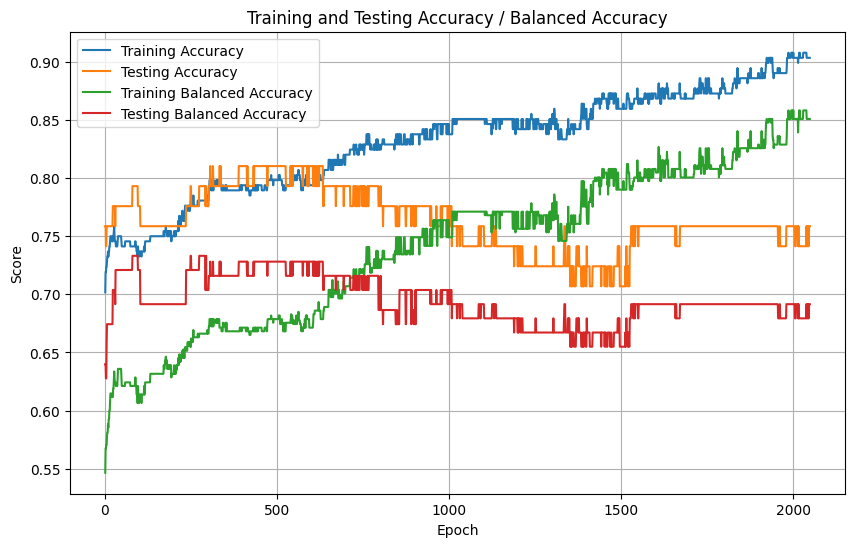

In [12]:
plt.figure(figsize=(10, 6))

plt.plot(history_df["epoch"], history_df["train_accuracy"], label="Training Accuracy")
plt.plot(history_df["epoch"], history_df["test_accuracy"], label="Testing Accuracy")
plt.plot(history_df["epoch"], history_df["train_balanced_accuracy"], label="Training Balanced Accuracy")
plt.plot(history_df["epoch"], history_df["test_balanced_accuracy"], label="Testing Balanced Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Training and Testing Accuracy / Balanced Accuracy")
plt.legend()
plt.grid(True)
plt.show()

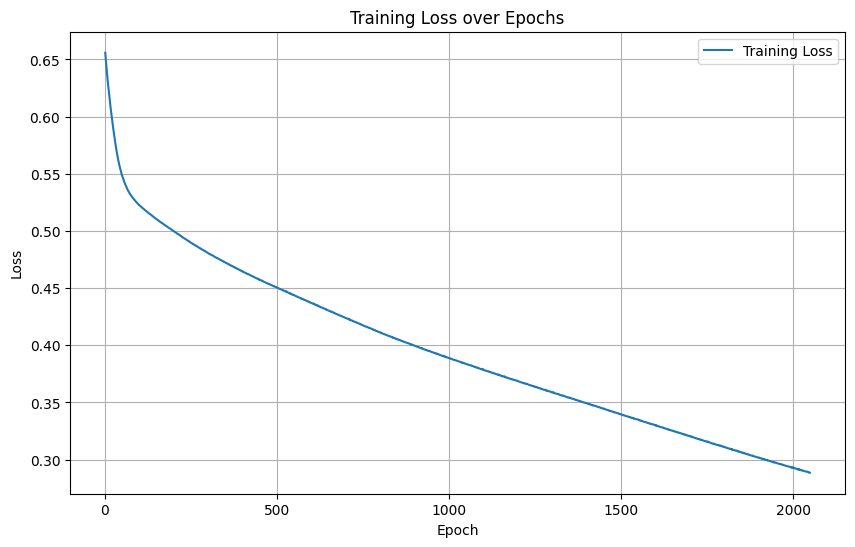

In [13]:
plt.figure(figsize=(10, 6))

plt.plot(history_df["epoch"], history_df["train_loss"], label="Training Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss over Epochs")
plt.legend()
plt.grid(True)
plt.show()

In [14]:
final_train_acc, final_train_bal_acc, _, _ = evaluate_model(
    model,
    X_train_tensor,
    y_train_tensor
)

final_test_acc, final_test_bal_acc, y_true_test, y_pred_test = evaluate_model(
    model,
    X_test_tensor,
    y_test_tensor
)

print("Final Results")
print("=============")
print(f"Training accuracy:           {final_train_acc:.4f}")
print(f"Training balanced accuracy:  {final_train_bal_acc:.4f}")
print(f"Testing accuracy:            {final_test_acc:.4f}")
print(f"Testing balanced accuracy:   {final_test_bal_acc:.4f}")

Final Results
Training accuracy:           0.9035
Training balanced accuracy:  0.8509
Testing accuracy:            0.7586
Testing balanced accuracy:   0.6915


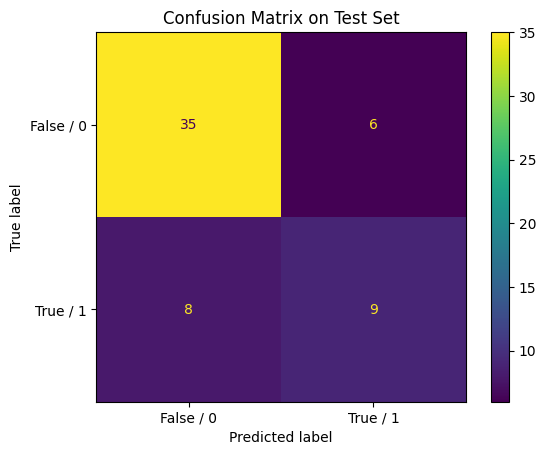

Raw confusion matrix:
[[35  6]
 [ 8  9]]


In [15]:
cm = confusion_matrix(y_true_test, y_pred_test)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["False / 0", "True / 1"]
)

disp.plot()
plt.title("Confusion Matrix on Test Set")
plt.show()

print("Raw confusion matrix:")
print(cm)

In [16]:
print(
    classification_report(
        y_true_test,
        y_pred_test,
        target_names=["False / 0", "True / 1"]
    )
)

              precision    recall  f1-score   support

   False / 0       0.81      0.85      0.83        41
    True / 1       0.60      0.53      0.56        17

    accuracy                           0.76        58
   macro avg       0.71      0.69      0.70        58
weighted avg       0.75      0.76      0.75        58

